# Density-Dependent False Removal Rate

How does spot density per cell affect the probability of spurious cross-channel nearest-neighbor matches?

**Plan:**
1. Load mouse data + mixed spots
2. Get cell volumes from the mixed CXG table (`dataset.get_cell_info`)
3. Compute per-cell, per-channel, per-round spot density (spots / µm³)
4. Derive the analytic false removal rate as a function of density for several NN thresholds
5. Overlay the real cell density distribution on the analytic curve

In [7]:
# ── Load data for density analysis ───────────────────────────────────────────
DENSITY_MOUSE_ID  = "782149"
DENSITY_CATALOG   = Path(f"/src/ophys-mfish-dataset-catalog/mice/{DENSITY_MOUSE_ID}.json")

density_record  = MouseRecord.from_json_file(DENSITY_CATALOG)
density_results = attach_mouse_record_to_workstation(density_record)
print_attach_results(density_results)

density_dataset = create_hcr_dataset_from_schema(DENSITY_CATALOG, DATA_DIR)
density_dataset.summary()

pairwise_asset_name_d = density_record.derived_assets.get("pairwise_unmixing")
if pairwise_asset_name_d is not None:
    pw_asset_path_d = DATA_DIR / pairwise_asset_name_d
    if (pw_asset_path_d / "pairwise_unmixing").exists():
        pw_asset_path_d = pw_asset_path_d / "pairwise_unmixing"
    pw_ds_d = create_pairwise_unmixing_dataset(
        mouse_id=DENSITY_MOUSE_ID,
        pairwise_asset_path=pw_asset_path_d,
        source_dataset=density_dataset,
    )
    pw_ds_d.summary()
else:
    print("No pairwise_unmixing asset found — skipping.")
    pw_ds_d = None

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-04-15_21-20-31  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['unmixe

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['mixed_spots_R-1.pkl', 'mixed_spots_R5.pkl', 'unmixed_spots_R5_minDist_3.pkl', 'unmixed_spots_R-1_minDist_3.pkl']
[DEBUG get_spot_files] unmixed_spots=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing/unmixed_spots_R5_minDist_3.pkl  mixed_spots=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing/mixed_spots_R5.pkl
mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 405, 488, 561, 594
  R2: 488, 514, 561, 638, 405, 594
  R3: 405, 561, 594, 638, 488, 514
  R4: 51

In [14]:

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

In [8]:
# ── Load mixed spots (all rounds) ────────────────────────────────────────────
mixed_all_d = pw_ds_d.load_all_rounds_spots_mp(table_type="mixed_spots", remove_fg_bg_cols=True)
print(f"Loaded {len(mixed_all_d):,} mixed spots across {mixed_all_d['round'].nunique()} rounds")
print(f"Columns: {mixed_all_d.columns.tolist()}")
mixed_all_d.head(3)

Loading mixed_spots for round R1: 782149_R1
Loading mixed_spots for round R2: 782149_R2

Loading mixed_spots for round R3: 782149_R3

Loading mixed_spots for round R4: 782149_R4
Loading mixed_spots for round R5: 782149_R5





Number of mixed_spots: 3.628e+07
Loaded 36,277,775 mixed spots across 5 rounds
Columns: ['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id', 'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity', 'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'mixed_gene', 'chan_514_intensity', 'chan_638_intensity']


,spot_id,spot_uid,spot_uid_int,chan,chan_spot_id,cell_id,round,z,y,x,dist,r,chan_488_intensity,chan_561_intensity,chan_594_intensity,over_thresh,mixed_gene,chan_514_intensity,chan_638_intensity
0,0,488_23,0,488,23,16,R1,69,788,573,0.571598,0.436765,201.593506,27.244551,32.674789,False,GFP,NaN,NaN
1,1,488_24,1,488,24,16,R1,67,771,611,2.515853,0.420315,1113.537354,32.000000,131.829895,True,GFP,NaN,NaN
2,2,488_25,2,488,25,16,R1,67,771,622,1.148331,0.066283,1304.138794,67.090080,150.424698,True,GFP,NaN,NaN


In [9]:
# ── Get cell volumes from mixed CXG table ────────────────────────────────────
# get_cell_info(source="mixed_cxg") returns: cell_id, volume (voxels), x/y/z_centroid
# Volume is in voxels; convert to µm³ using voxel size (x=0.24, y=0.24, z=1.0 µm)
VOXEL_SIZE_UM3 = 0.24 * 0.24 * 1.0  # µm³ per voxel

cell_info_d = density_dataset.get_cell_info(source="mixed_cxg")
cell_info_d["volume_um3"] = cell_info_d["volume"] * VOXEL_SIZE_UM3

print(f"Cell info: {len(cell_info_d):,} cells")
print(f"Volume range: {cell_info_d['volume_um3'].min():.1f} – {cell_info_d['volume_um3'].max():.1f} µm³")
print(f"Median volume: {cell_info_d['volume_um3'].median():.1f} µm³")
cell_info_d.head(3)

Loading mixed cxg for round R1


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R2


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R3


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R4


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R5
Cell info: 35,449 cells
Volume range: 15.7 – 86591.7 µm³
Median volume: 7701.8 µm³


,cell_id,volume,x_centroid,y_centroid,z_centroid,volume_um3
0,2,5280.0,600,1046,119,304.1280
1,3,2672.0,198,136,121,153.9072
2,5,5136.0,204,170,121,295.8336


In [36]:

# ── Compute per-cell, per-channel, per-round spot density ────────────────────
MIN_SPOTS = 25  # minimum spots required in a cell×channel×round to include

spot_counts_d = (
    mixed_all_d
    .groupby(["round", "cell_id", "chan"])
    .size()
    .reset_index(name="n_spots")
)

# Filter out low-count cell×channel×round combos before computing density
spot_counts_d = spot_counts_d[spot_counts_d["n_spots"] >= MIN_SPOTS]

density_df = spot_counts_d.merge(
    cell_info_d[["cell_id", "volume_um3"]],
    on="cell_id",
    how="inner",
)
density_df["density_um3"] = density_df["n_spots"] / density_df["volume_um3"]

print(f"Density table: {len(density_df):,} rows  (min_spots >= {MIN_SPOTS})")
print(f"\nMedian density by channel (all rounds pooled):")
print(
    density_df.groupby("chan")["density_um3"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .round(4)
)
density_df.head(5)


Density table: 280,349 rows  (min_spots >= 25)

Median density by channel (all rounds pooled):
        count    mean     std     min     25%     50%     75%     95%     max
chan                                                                         
488   73480.0  0.0147  0.0119  0.0004  0.0057  0.0128  0.0194  0.0330  0.2463
514   61626.0  0.0093  0.0061  0.0005  0.0047  0.0079  0.0123  0.0196  0.0786
561   79681.0  0.0194  0.0144  0.0005  0.0060  0.0166  0.0320  0.0420  0.2309
594   58273.0  0.0090  0.0140  0.0004  0.0039  0.0054  0.0084  0.0283  0.3569
638    7289.0  0.0166  0.0184  0.0003  0.0031  0.0094  0.0235  0.0575  0.1951


,round,cell_id,chan,n_spots,volume_um3,density_um3
0,R1,13,594,26,263.5776,0.098643
1,R1,16,488,457,37514.6496,0.012182
2,R1,16,561,340,37514.6496,0.009063
3,R1,16,594,745,37514.6496,0.019859
4,R1,17,488,84,41564.1600,0.002021


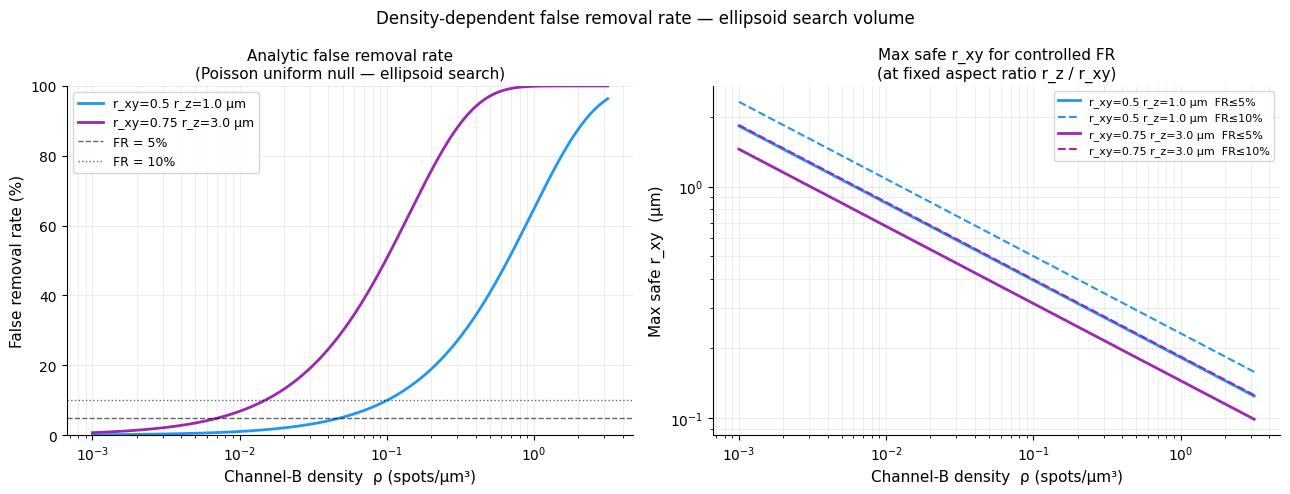

In [33]:

# ── Analytic false removal rate — ellipsoid search volume ────────────────────
# Model: spots in channel B placed uniformly at random.
# P(nearest B neighbor inside ellipsoid(r_xy, r_z)) = 1 - exp(-ρ_B * V_ellipsoid)
# V_ellipsoid = (4/3) * π * r_xy² * r_z

def ellipsoid_volume(r_xy, r_z):
    """Volume of ellipsoid with equal semi-axes r_xy (x=y) and r_z."""
    return (4 / 3) * np.pi * r_xy**2 * r_z

def false_removal_rate(rho_b, r_xy, r_z):
    """Poisson void probability: fraction of A-spots with NN_B inside ellipsoid by chance."""
    return 1 - np.exp(-rho_b * ellipsoid_volume(r_xy, r_z))

def breakeven_density(r_xy, r_z, alpha=0.05):
    """Density at which the ellipsoid gives exactly 'alpha' false removal rate."""
    return -np.log(1 - alpha) / ellipsoid_volume(r_xy, r_z)

def safe_rxy(rho_b, aspect_ratio, alpha=0.05):
    """Max r_xy (µm) for fixed AR = r_z/r_xy such that FR <= alpha.
    Inverts: FR = 1 - exp(-ρ * (4/3)π * AR * r_xy³) = alpha
    """
    return ((-3 * np.log(1 - alpha)) / (4 * np.pi * aspect_ratio * rho_b)) ** (1 / 3)

rho_axis = np.logspace(-3, 0.5, 400)  # 0.001 → ~3 spots/µm³

ELLIPSOIDS = [
    {"r_xy": 0.50, "r_z": 1.0, "color": "#2196F3", "label": "r_xy=0.5 r_z=1.0 µm"},
    {"r_xy": 0.75, "r_z": 3.0, "color": "#9C27B0", "label": "r_xy=0.75 r_z=3.0 µm"},
]
THRESHOLD_COLORS = [e["color"] for e in ELLIPSOIDS]  # kept for downstream compat

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: FR vs density for each ellipsoid ───────────────────────────────────
ax = axes[0]
for e in ELLIPSOIDS:
    fr = false_removal_rate(rho_axis, e["r_xy"], e["r_z"])
    ax.plot(rho_axis, fr * 100, color=e["color"], linewidth=2, label=e["label"])

ax.axhline(5,  color="black", linestyle="--", linewidth=1, alpha=0.6, label="FR = 5%")
ax.axhline(10, color="black", linestyle=":",  linewidth=1, alpha=0.6, label="FR = 10%")
ax.set_xscale("log")
ax.set_xlabel("Channel-B density  ρ (spots/µm³)", fontsize=11)
ax.set_ylabel("False removal rate (%)", fontsize=11)
ax.set_title("Analytic false removal rate\n(Poisson uniform null — ellipsoid search)", fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, which="both", linewidth=0.4, alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

# ── Right: safe r_xy vs density (for each aspect ratio) ──────────────────────
ax2 = axes[1]
for e in ELLIPSOIDS:
    ar = e["r_z"] / e["r_xy"]
    for alpha, ls, lw, pct in [(0.05, "-", 2, 5), (0.10, "--", 1.5, 10)]:
        safe = safe_rxy(rho_axis, ar, alpha)
        ax2.plot(rho_axis, safe, linewidth=lw, linestyle=ls,
                 color=e["color"], label=f"{e['label']}  FR≤{pct}%")

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Channel-B density  ρ (spots/µm³)", fontsize=11)
ax2.set_ylabel("Max safe r_xy  (µm)", fontsize=11)
ax2.set_title("Max safe r_xy for controlled FR\n(at fixed aspect ratio r_z / r_xy)", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, which="both", linewidth=0.4, alpha=0.4)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle("Density-dependent false removal rate — ellipsoid search volume", fontsize=12)
fig.tight_layout()
plt.show()


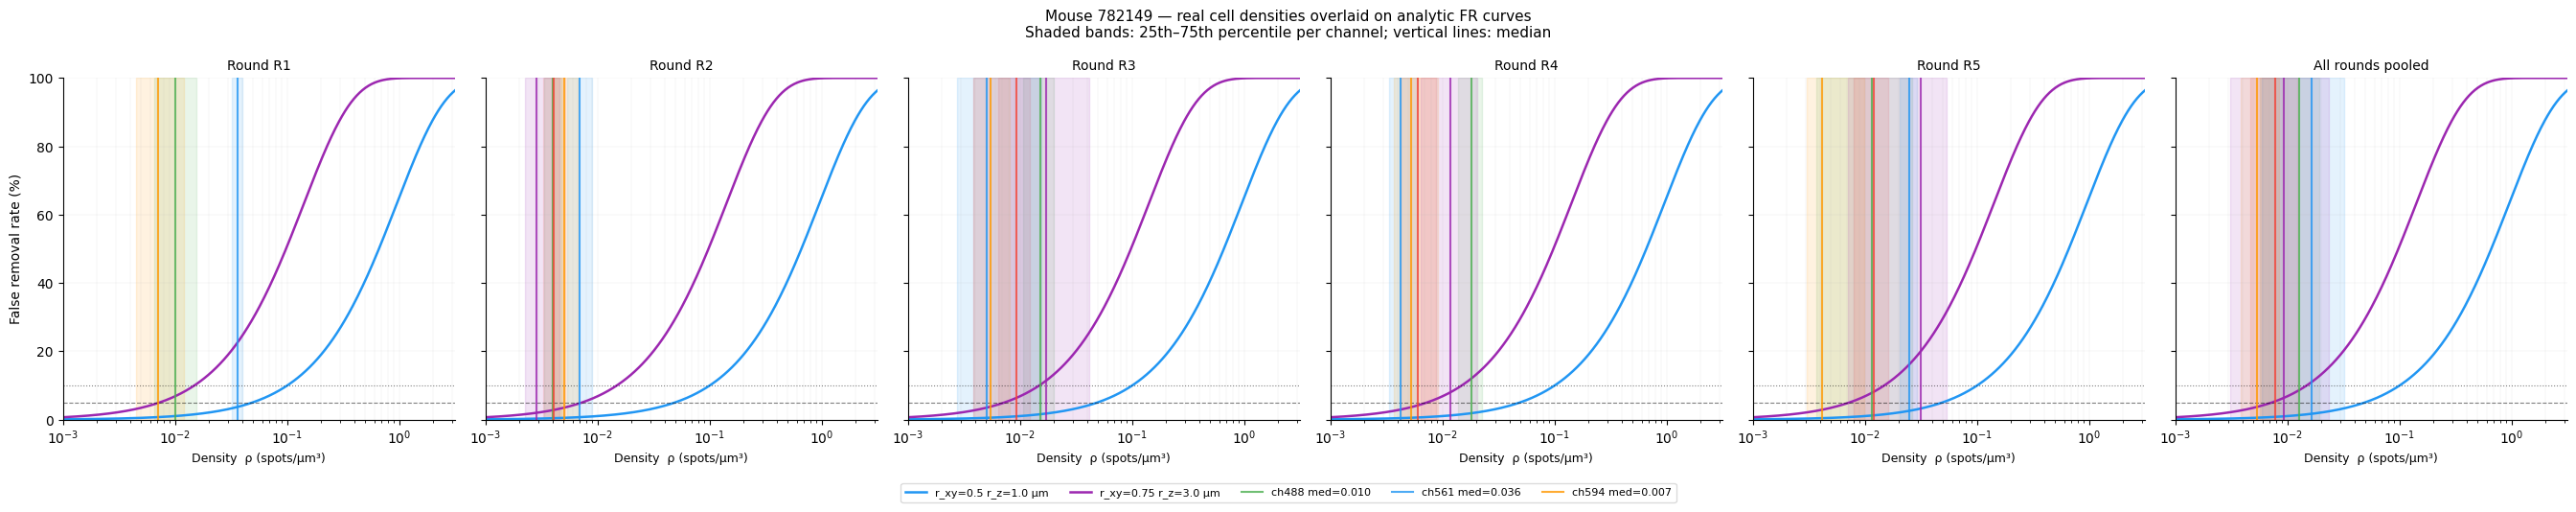

In [34]:

# ── Overlay real cell densities on the FR curve ───────────────────────────────
rounds_present = sorted(density_df["round"].unique())
chans_present  = [c for c in CHAN_ORDER if c in density_df["chan"].unique()]

ncols = len(rounds_present) + 1
fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 5), sharey=True)

def _overlay_panel(ax, data_subset, title):
    """Draw FR analytic curves (ellipsoid) + real density bands on one axes."""
    for e in ELLIPSOIDS:
        fr = false_removal_rate(rho_axis, e["r_xy"], e["r_z"])
        ax.plot(rho_axis, fr * 100, color=e["color"], linewidth=1.8, label=e["label"])

    ax.axhline(5,  color="k", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(10, color="k", linestyle=":",  linewidth=0.8, alpha=0.5)

    for chan in chans_present:
        sub = data_subset[data_subset["chan"] == chan]["density_um3"]
        if len(sub) < 5:
            continue
        p25, p50, p75 = sub.quantile([0.25, 0.50, 0.75])
        chan_color = CHAN_COLORS.get(chan, "grey")
        ax.axvspan(p25, p75, alpha=0.12, color=chan_color)
        ax.axvline(p50, color=chan_color, linewidth=1.5, alpha=0.8,
                   label=f"ch{chan} med={p50:.3f}")

    ax.set_xscale("log")
    ax.set_xlim(rho_axis[0], rho_axis[-1])
    ax.set_ylim(0, 100)
    ax.set_xlabel("Density  ρ (spots/µm³)", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(True, which="both", linewidth=0.3, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("False removal rate (%)", fontsize=10)

for i, rk in enumerate(rounds_present):
    _overlay_panel(axes[i], density_df[density_df["round"] == rk], f"Round {rk}")

_overlay_panel(axes[-1], density_df, "All rounds pooled")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(handles),
           fontsize=8, bbox_to_anchor=(0.5, -0.06), framealpha=0.7)

fig.suptitle(
    f"Mouse {DENSITY_MOUSE_ID} — real cell densities overlaid on analytic FR curves\n"
    "Shaded bands: 25th–75th percentile per channel; vertical lines: median",
    fontsize=11,
)
fig.tight_layout()
plt.show()


In [38]:

# ── Summary: FR at real cell densities for each ellipsoid ────────────────────
for i, e in enumerate(ELLIPSOIDS):
    col = f"fr_ellipsoid_{i}"
    density_df[col] = false_removal_rate(density_df["density_um3"], e["r_xy"], e["r_z"]) * 100
    density_df[f"overcrowded_e{i}"] = density_df[col] > 5.0  # >5% FR

print("=== FR (%) at real cell densities — by channel (all rounds pooled) ===")
fr_cols = [f"fr_ellipsoid_{i}" for i in range(len(ELLIPSOIDS))]
summary = (
    density_df
    .groupby("chan")[["density_um3"] + fr_cols]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(3)
)
print(summary.to_string())

print(f"\n--- Fraction of cell×channel combos with >5% FR per ellipsoid ---")
for i, e in enumerate(ELLIPSOIDS):
    print(f"\n  Ellipsoid {i+1}: {e['label']}")
    print(
        density_df.groupby(["round", "chan"])[f"overcrowded_e{i}"]
        .mean()
        .mul(100)
        .round(1)
        .rename("% >5% FR")
        .to_string()
    )


=== FR (%) at real cell densities — by channel (all rounds pooled) ===
     density_um3                                                  fr_ellipsoid_0                                                   fr_ellipsoid_1                                                      
           count   mean    std    min    25%    50%    75%    max          count   mean    std    min    25%    50%    75%     max          count    mean     std    min    25%     50%     75%     max
chan                                                                                                                                                                                                   
488      73480.0  0.015  0.012  0.000  0.006  0.013  0.019  0.246        73480.0  1.520  1.209  0.046  0.598  1.333  2.013  22.731        73480.0   9.573   6.904  0.307  3.971   8.660  12.828  82.460
514      61626.0  0.009  0.006  0.000  0.005  0.008  0.012  0.079        61626.0  0.963  0.630  0.051  0.493  0.819  1.277   7.90

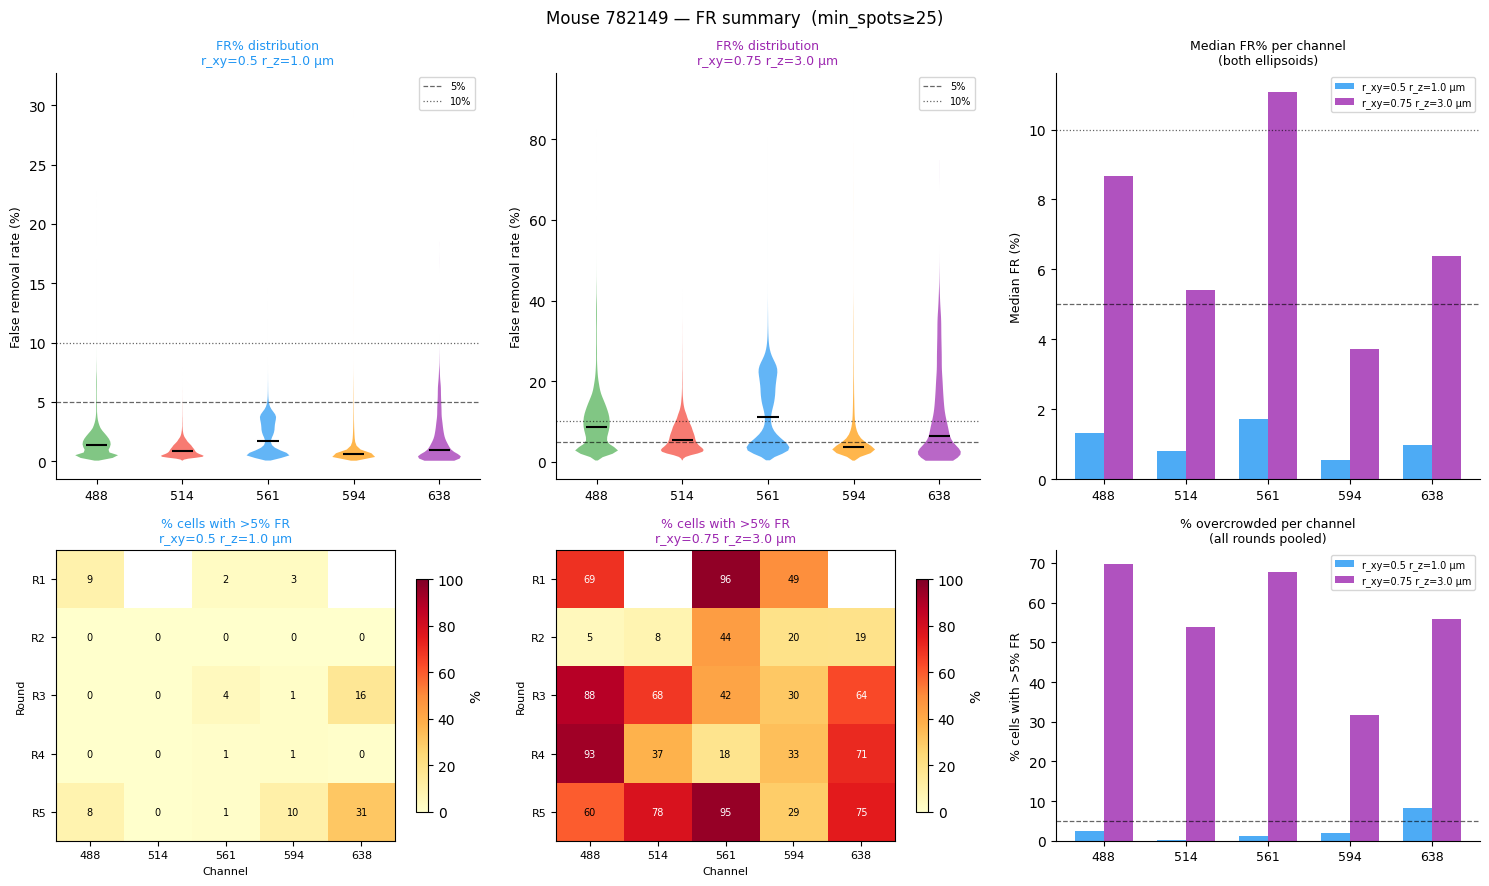

In [39]:

# ── Summary plots of the FR table ────────────────────────────────────────────
# Ensure FR columns are present (computed in the summary table cell above)
for i, e in enumerate(ELLIPSOIDS):
    col = f"fr_ellipsoid_{i}"
    if col not in density_df.columns:
        density_df[col] = false_removal_rate(density_df["density_um3"], e["r_xy"], e["r_z"]) * 100
        density_df[f"overcrowded_e{i}"] = density_df[col] > 5.0

# Left block:  violin/boxplot of FR% per channel for each ellipsoid
# Right block: heatmap of % cells with >5% FR per round×channel per ellipsoid

n_e = len(ELLIPSOIDS)
fig, axes = plt.subplots(2, n_e + 1, figsize=(5 * (n_e + 1), 9),
                          gridspec_kw={"height_ratios": [1.4, 1]})

# ── Row 0: FR% violin per channel ─────────────────────────────────────────────
chans_ord = [c for c in CHAN_ORDER if c in density_df["chan"].unique()]
for ei, e in enumerate(ELLIPSOIDS):
    ax = axes[0, ei]
    fr_col = f"fr_ellipsoid_{ei}"
    data_by_chan = [density_df.loc[density_df["chan"] == c, fr_col].to_numpy() for c in chans_ord]

    parts = ax.violinplot(data_by_chan, positions=range(len(chans_ord)),
                          showmedians=True, showextrema=False)
    for pc, chan in zip(parts["bodies"], chans_ord):
        pc.set_facecolor(CHAN_COLORS.get(chan, "grey"))
        pc.set_alpha(0.7)
    parts["cmedians"].set_edgecolor("black")
    parts["cmedians"].set_linewidth(1.5)

    ax.axhline(5,  color="k", linestyle="--", linewidth=0.9, alpha=0.6, label="5%")
    ax.axhline(10, color="k", linestyle=":",  linewidth=0.9, alpha=0.6, label="10%")
    ax.set_xticks(range(len(chans_ord)))
    ax.set_xticklabels(chans_ord, fontsize=9)
    ax.set_ylabel("False removal rate (%)", fontsize=9)
    ax.set_title(f"FR% distribution\n{e['label']}", fontsize=9, color=e["color"])
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

# ── Row 0, last col: median FR% per channel side-by-side bar ─────────────────
ax_bar = axes[0, n_e]
x = np.arange(len(chans_ord))
width = 0.35
for ei, e in enumerate(ELLIPSOIDS):
    fr_col = f"fr_ellipsoid_{ei}"
    medians = [density_df.loc[density_df["chan"] == c, fr_col].median() for c in chans_ord]
    ax_bar.bar(x + ei * width - width / 2, medians, width,
               color=e["color"], alpha=0.8, label=e["label"])

ax_bar.axhline(5,  color="k", linestyle="--", linewidth=0.9, alpha=0.6)
ax_bar.axhline(10, color="k", linestyle=":",  linewidth=0.9, alpha=0.6)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(chans_ord, fontsize=9)
ax_bar.set_ylabel("Median FR (%)", fontsize=9)
ax_bar.set_title("Median FR% per channel\n(both ellipsoids)", fontsize=9)
ax_bar.legend(fontsize=7)
ax_bar.spines[["top", "right"]].set_visible(False)

# ── Row 1: heatmap % cells with >5% FR per round×channel ─────────────────────
for ei, e in enumerate(ELLIPSOIDS):
    ax = axes[1, ei]
    oc_col = f"overcrowded_e{ei}"
    heat = (
        density_df.groupby(["round", "chan"])[oc_col]
        .mean()
        .mul(100)
        .unstack("chan")
        .reindex(columns=chans_ord)
    )
    heat = heat.sort_index()

    im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=100)
    ax.set_xticks(range(len(chans_ord)))
    ax.set_xticklabels(chans_ord, fontsize=8)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index.tolist(), fontsize=8)
    ax.set_title(f"% cells with >5% FR\n{e['label']}", fontsize=9, color=e["color"])
    ax.set_xlabel("Channel", fontsize=8)
    ax.set_ylabel("Round", fontsize=8)
    for ri, rnd in enumerate(heat.index):
        for ci, chan in enumerate(chans_ord):
            val = heat.loc[rnd, chan]
            if not np.isnan(val):
                ax.text(ci, ri, f"{val:.0f}", ha="center", va="center",
                        fontsize=7, color="black" if val < 60 else "white")
    plt.colorbar(im, ax=ax, shrink=0.8, label="%")

# ── Row 1, last col: pooled (all rounds) % overcrowded bar ────────────────────
ax_oc = axes[1, n_e]
x = np.arange(len(chans_ord))
for ei, e in enumerate(ELLIPSOIDS):
    oc_col = f"overcrowded_e{ei}"
    vals = [density_df.loc[density_df["chan"] == c, oc_col].mean() * 100 for c in chans_ord]
    ax_oc.bar(x + ei * width - width / 2, vals, width,
              color=e["color"], alpha=0.8, label=e["label"])

ax_oc.axhline(5, color="k", linestyle="--", linewidth=0.9, alpha=0.6)
ax_oc.set_xticks(x)
ax_oc.set_xticklabels(chans_ord, fontsize=9)
ax_oc.set_ylabel("% cells with >5% FR", fontsize=9)
ax_oc.set_title("% overcrowded per channel\n(all rounds pooled)", fontsize=9)
ax_oc.legend(fontsize=7)
ax_oc.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Mouse {DENSITY_MOUSE_ID} — FR summary  (min_spots≥{MIN_SPOTS})",
    fontsize=12,
)
fig.tight_layout()
plt.show()


Cells in top 10% for at least one channel: 19,158
Rows in dense_df: 388,157

Density stats for top-10% pool — by channel (all rounds pooled):
        count    mean     std     min     25%     50%     75%     max
chan                                                                 
488   85093.0  0.0118  0.0134  0.0001  0.0025  0.0073  0.0176  0.3067
514   68456.0  0.0082  0.0073  0.0001  0.0030  0.0062  0.0117  0.1789
561   88388.0  0.0157  0.0161  0.0000  0.0031  0.0080  0.0279  0.2309
594   86343.0  0.0085  0.0176  0.0000  0.0019  0.0040  0.0075  0.3569
638   59877.0  0.0031  0.0088  0.0000  0.0004  0.0008  0.0016  0.2831


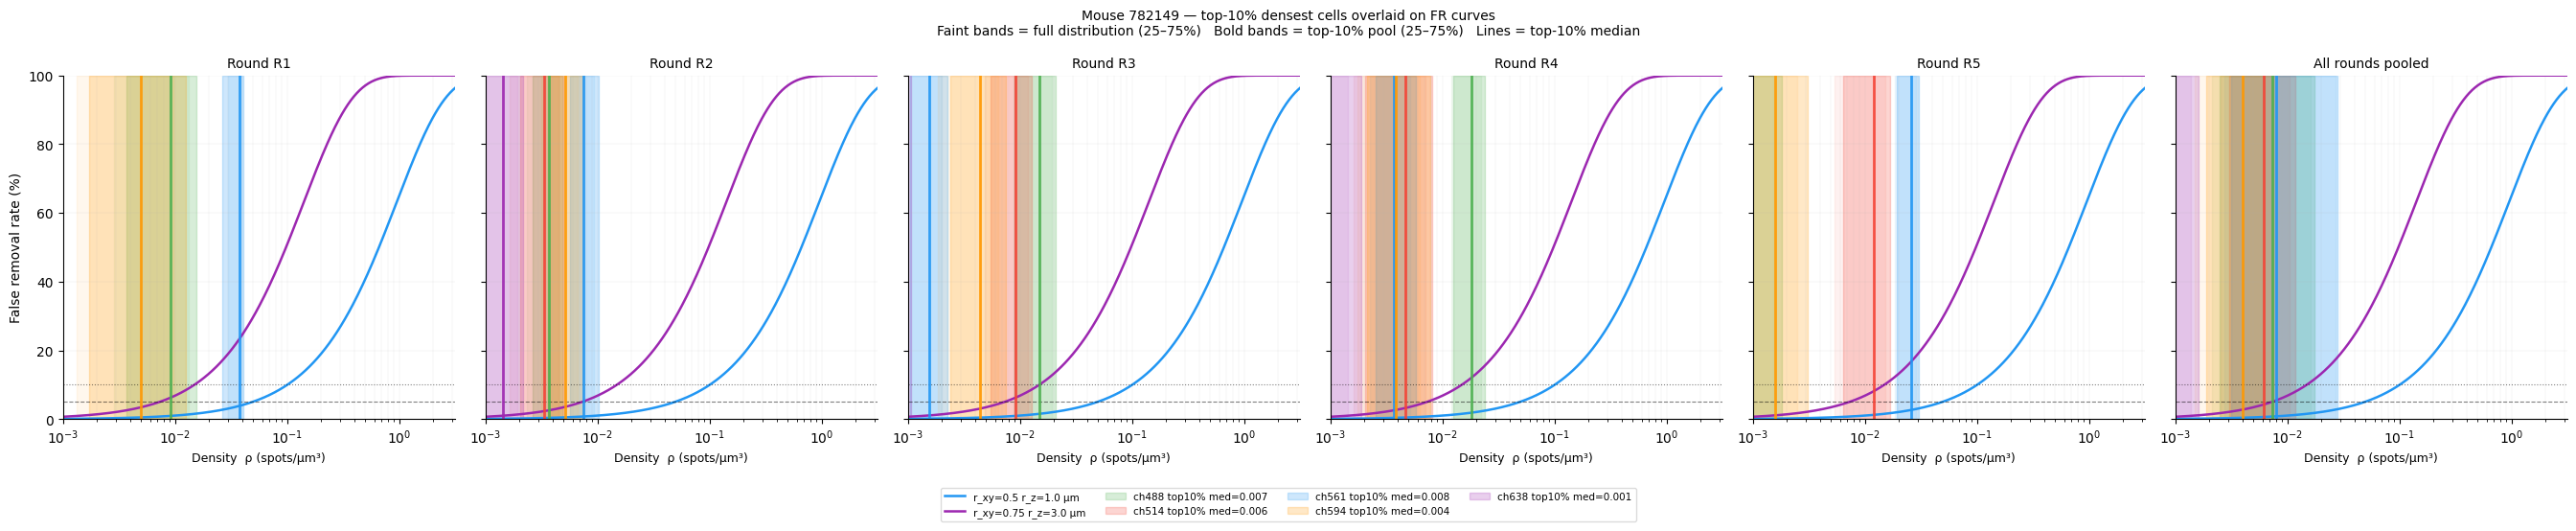

In [26]:

# ── Top-10% densest cells per channel: overlay on FR curves ──────────────────
P90 = 0.90

top10_ids_by_chan = {}
for chan in chans_present:
    sub = density_df[density_df["chan"] == chan]
    thresh = sub["density_um3"].quantile(P90)
    top10_ids_by_chan[chan] = set(sub.loc[sub["density_um3"] >= thresh, "cell_id"])

all_top10_ids = set.union(*top10_ids_by_chan.values())
dense_df = density_df[density_df["cell_id"].isin(all_top10_ids)].copy()

print(f"Cells in top 10% for at least one channel: {len(all_top10_ids):,}")
print(f"Rows in dense_df: {len(dense_df):,}")
print(f"\nDensity stats for top-10% pool — by channel (all rounds pooled):")
print(dense_df.groupby("chan")["density_um3"].describe(percentiles=[0.25, 0.5, 0.75]).round(4).to_string())

ncols = len(rounds_present) + 1
fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 5), sharey=True)

def _overlay_dense_panel(ax, all_data, dense_data, title):
    for e in ELLIPSOIDS:
        ax.plot(rho_axis, false_removal_rate(rho_axis, e["r_xy"], e["r_z"]) * 100,
                color=e["color"], linewidth=1.8, label=e["label"])
    ax.axhline(5,  color="k", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(10, color="k", linestyle=":",  linewidth=0.8, alpha=0.5)

    for chan in chans_present:
        chan_color = CHAN_COLORS.get(chan, "grey")
        full_sub = all_data[all_data["chan"] == chan]["density_um3"]
        if len(full_sub) >= 5:
            ax.axvspan(full_sub.quantile(0.25), full_sub.quantile(0.75),
                       alpha=0.07, color=chan_color)

        d_sub = dense_data[dense_data["chan"] == chan]["density_um3"]
        if len(d_sub) < 3:
            continue
        p25d, p50d, p75d = d_sub.quantile(0.25), d_sub.quantile(0.50), d_sub.quantile(0.75)
        ax.axvspan(p25d, p75d, alpha=0.22, color=chan_color,
                   label=f"ch{chan} top10% med={p50d:.3f}")
        ax.axvline(p50d, color=chan_color, linewidth=2.0, alpha=0.9)

    ax.set_xscale("log")
    ax.set_xlim(rho_axis[0], rho_axis[-1])
    ax.set_ylim(0, 100)
    ax.set_xlabel("Density  ρ (spots/µm³)", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(True, which="both", linewidth=0.3, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("False removal rate (%)", fontsize=10)

for i, rnd in enumerate(rounds_present):
    _overlay_dense_panel(
        axes[i],
        density_df[density_df["round"] == rnd],
        dense_df[dense_df["round"] == rnd],
        f"Round {rnd}",
    )
_overlay_dense_panel(axes[-1], density_df, dense_df, "All rounds pooled")

handles, labels_leg = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=4,
           fontsize=7.5, bbox_to_anchor=(0.5, -0.10), framealpha=0.7)

fig.suptitle(
    f"Mouse {DENSITY_MOUSE_ID} — top-10% densest cells overlaid on FR curves\n"
    "Faint bands = full distribution (25–75%)   Bold bands = top-10% pool (25–75%)   Lines = top-10% median",
    fontsize=10,
)
fig.tight_layout()
plt.show()


All-channel pooled density (full pop):  p10=0.0005  p50=0.0040  p90=0.0249
All-channel pooled density (top-10%):   p25=0.0016  p50=0.0046  p75=0.0126

Focal ellipsoid: r_xy=0.5 r_z=1.0 µm
  FR=5%  breakeven density: 0.0490 spots/µm³
  FR=10% breakeven density: 0.1006 spots/µm³


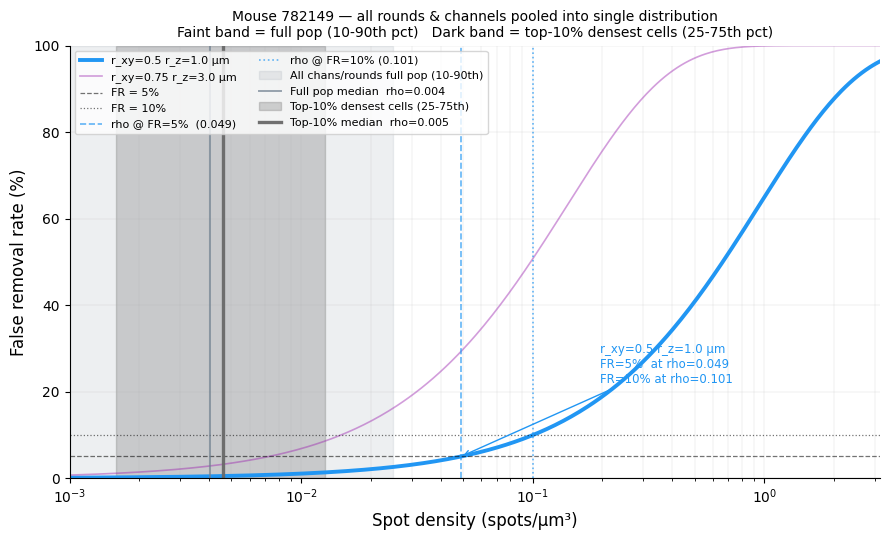

In [27]:

# ── Final summary plot: all rounds x all channels pooled ─────────────────────
FOCAL = ELLIPSOIDS[0]  # r_xy=0.5, r_z=1.0 µm
rho_focal_5  = breakeven_density(FOCAL["r_xy"], FOCAL["r_z"], 0.05)
rho_focal_10 = breakeven_density(FOCAL["r_xy"], FOCAL["r_z"], 0.10)

all_densities     = density_df["density_um3"]
all_densities_top = dense_df["density_um3"]

p10, p25, p50, p75, p90 = all_densities.quantile([0.10, 0.25, 0.50, 0.75, 0.90])
p25d, p50d, p75d        = all_densities_top.quantile([0.25, 0.50, 0.75])

print(f"All-channel pooled density (full pop):  p10={p10:.4f}  p50={p50:.4f}  p90={p90:.4f}")
print(f"All-channel pooled density (top-10%):   p25={p25d:.4f}  p50={p50d:.4f}  p75={p75d:.4f}")
print(f"\nFocal ellipsoid: {FOCAL['label']}")
print(f"  FR=5%  breakeven density: {rho_focal_5:.4f} spots/µm³")
print(f"  FR=10% breakeven density: {rho_focal_10:.4f} spots/µm³")

fig, ax = plt.subplots(figsize=(9, 5.5))

# ── Analytic FR curves ────────────────────────────────────────────────────────
for e in ELLIPSOIDS:
    is_focal = (e is FOCAL)
    fr = false_removal_rate(rho_axis, e["r_xy"], e["r_z"])
    ax.plot(rho_axis, fr * 100,
            color=e["color"], linewidth=2.8 if is_focal else 1.2,
            alpha=1.0 if is_focal else 0.45, label=e["label"])

ax.axhline(5,  color="k", linestyle="--", linewidth=0.9, alpha=0.55, label="FR = 5%")
ax.axhline(10, color="k", linestyle=":",  linewidth=0.9, alpha=0.55, label="FR = 10%")

ax.axvline(rho_focal_5,  color=FOCAL["color"], linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"rho @ FR=5%  ({rho_focal_5:.3f})")
ax.axvline(rho_focal_10, color=FOCAL["color"], linestyle=":",  linewidth=1.2, alpha=0.7,
           label=f"rho @ FR=10% ({rho_focal_10:.3f})")

# ── Mega-distribution overlays ───────────────────────────────────────────────
FULL_COLOR = "slategray"
TOP_COLOR  = "dimgray"

ax.axvspan(p10, p90, alpha=0.12, color=FULL_COLOR, label="All chans/rounds full pop (10-90th)")
ax.axvline(p50, color=FULL_COLOR, linewidth=1.4, alpha=0.7, linestyle="-",
           label=f"Full pop median  rho={p50:.3f}")

ax.axvspan(p25d, p75d, alpha=0.28, color=TOP_COLOR, label="Top-10% densest cells (25-75th)")
ax.axvline(p50d, color=TOP_COLOR, linewidth=2.4, alpha=0.95,
           label=f"Top-10% median  rho={p50d:.3f}")

ax.set_xscale("log")
ax.set_xlim(rho_axis[0], rho_axis[-1])
ax.set_ylim(0, 100)
ax.set_xlabel("Spot density (spots/µm³)", fontsize=12)
ax.set_ylabel("False removal rate (%)", fontsize=12)
ax.grid(True, which="both", linewidth=0.35, alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.annotate(
    f"{FOCAL['label']}\nFR=5%  at rho={rho_focal_5:.3f}\nFR=10% at rho={rho_focal_10:.3f}",
    xy=(rho_focal_5, 5), xytext=(rho_focal_5 * 4, 22),
    fontsize=8.5, color=FOCAL["color"],
    arrowprops=dict(arrowstyle="->", color=FOCAL["color"], lw=1.0),
)

ax.legend(fontsize=8, loc="upper left", framealpha=0.8, ncol=2)
ax.set_title(
    f"Mouse {DENSITY_MOUSE_ID} — all rounds & channels pooled into single distribution\n"
    "Faint band = full pop (10-90th pct)   Dark band = top-10% densest cells (25-75th pct)",
    fontsize=10,
)
fig.tight_layout()
plt.show()


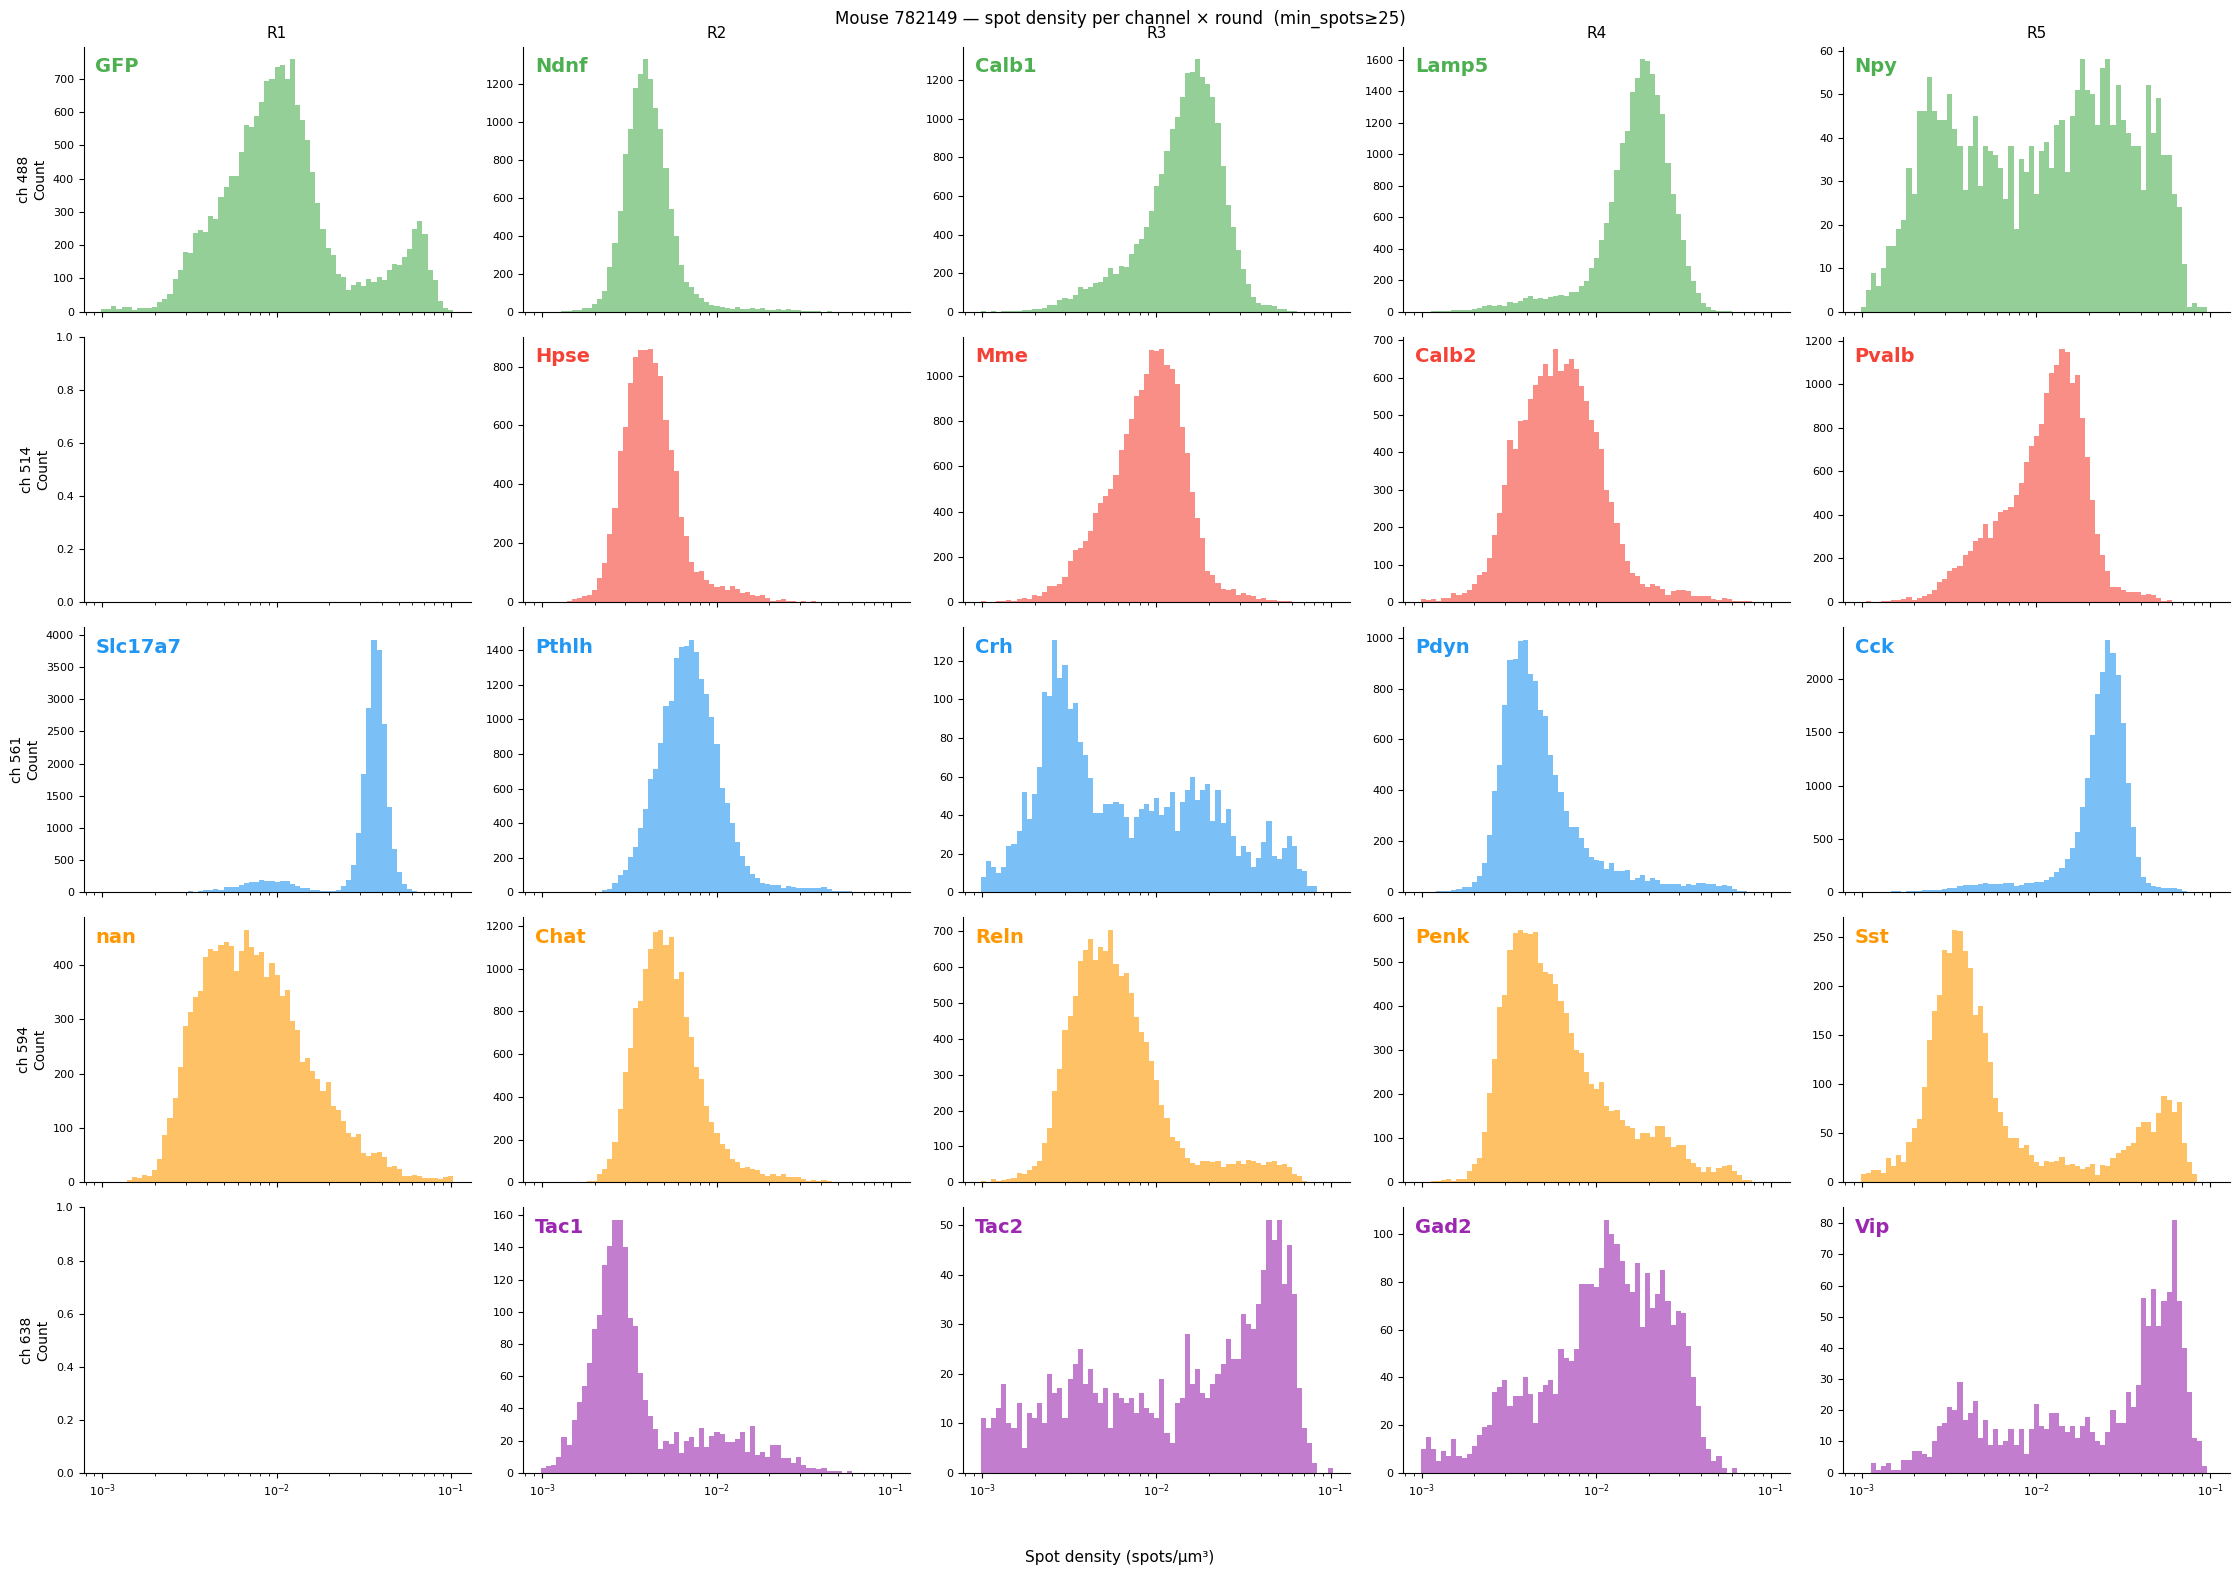

In [44]:

# ── Density histogram: all cells × all rounds, split by channel ───────────────
# Rows = channels, columns = rounds.

_rounds = rounds_present  # each round has a different gene — no pooled column
_chans  = chans_present

# Build channel → gene mapping per round from mixed spots
_gene_col = next((c for c in ["mixed_gene", "gene"] if c in mixed_all_d.columns), None)
_chan_round_to_gene = {}
if _gene_col:
    for (rnd, chan), grp in mixed_all_d.groupby(["round", "chan"]):
        _chan_round_to_gene[(rnd, chan)] = grp[_gene_col].iloc[0]

fig, axes = plt.subplots(
    len(_chans), len(_rounds),
    figsize=(4.5 * len(_rounds), 3.2 * len(_chans)),
    sharey=False, sharex=True,
)

# Pre-compute log-spaced bins from the full population once
_pooled_vals = density_df["density_um3"].to_numpy()
_bins = np.logspace(
    np.log10(np.quantile(_pooled_vals, 0.001)),
    np.log10(np.quantile(_pooled_vals, 0.999)), 70
)

for ci, chan in enumerate(_chans):
    chan_color = CHAN_COLORS.get(chan, "grey")
    for ri, rk_label in enumerate(_rounds):
        ax = axes[ci, ri]

        sub = density_df[(density_df["chan"] == chan) & (density_df["round"] == rk_label)]["density_um3"].to_numpy()

        if len(sub) > 0:
            counts, edges = np.histogram(sub, bins=_bins)
            ax.stairs(counts, edges, fill=True, color=chan_color, alpha=0.6, linewidth=0.5)

        gene_label = _chan_round_to_gene.get((rk_label, chan), "")
        if gene_label:
            ax.text(0.03, 0.96, gene_label, transform=ax.transAxes,
                    fontsize=14, va="top", ha="left",
                    color=chan_color, fontweight="bold")

        ax.set_xscale("log")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)

        if ci == 0:
            ax.set_title(rk_label, fontsize=11)
        if ri == 0:
            ax.set_ylabel(f"ch {chan}\nCount", fontsize=10)

fig.text(0.5, 0.01, "Spot density (spots/µm³)", ha="center", fontsize=11)
fig.suptitle(
    f"Mouse {DENSITY_MOUSE_ID} — spot density per channel × round  (min_spots≥{MIN_SPOTS})",
    fontsize=12,
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


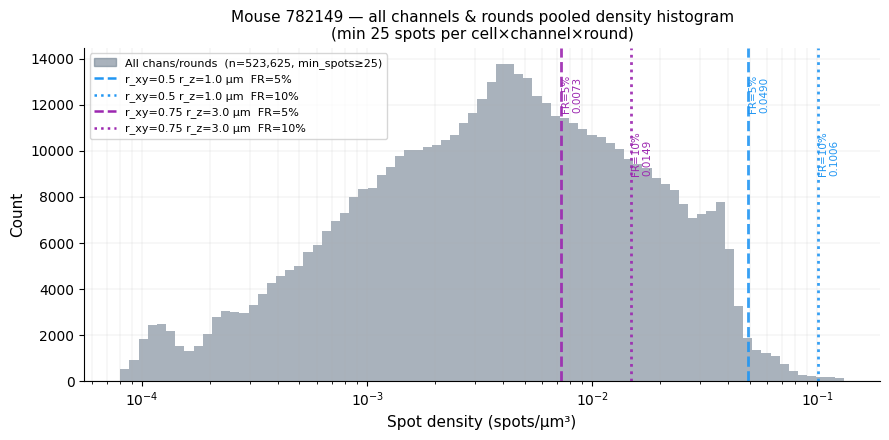

In [31]:

MIN_SPOTS = 25
# ── All rounds & channels pooled — single density histogram ──────────────────
from matplotlib.lines import Line2D

pooled_vals = density_df["density_um3"].to_numpy()
bins = np.logspace(
    np.log10(np.quantile(pooled_vals, 0.001)),
    np.log10(np.quantile(pooled_vals, 0.999)), 80
)
hist_counts, hist_edges = np.histogram(pooled_vals, bins=bins)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.stairs(hist_counts, hist_edges, fill=True, color="slategray", alpha=0.6,
          label=f"All channels & rounds  (n={len(pooled_vals):,})")

for e in ELLIPSOIDS:
    for alpha_val, ls, pct in [(0.05, "--", 5), (0.10, ":", 10)]:
        rho_be = breakeven_density(e["r_xy"], e["r_z"], alpha_val)
        ax.axvline(rho_be, color=e["color"], linestyle=ls, linewidth=2.0, alpha=0.9)
        ax.annotate(
            f"FR={pct}%\n{rho_be:.4f}",
            xy=(rho_be, 0.92 if pct == 5 else 0.75),
            xycoords=("data", "axes fraction"),
            fontsize=7.5, color=e["color"], va="top", ha="left",
            rotation=90,
        )

ax.set_xscale("log")
ax.set_xlabel("Spot density (spots/µm³)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.grid(True, which="both", linewidth=0.35, alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    mpatches.Patch(color="slategray", alpha=0.6, label=f"All chans/rounds  (n={len(pooled_vals):,}, min_spots≥{MIN_SPOTS})")
] + [
    Line2D([0], [0], color=e["color"], linestyle=ls, linewidth=1.8,
           label=f"{e['label']}  FR={pct}%")
    for e in ELLIPSOIDS
    for ls, pct in [("--", 5), (":", 10)]
]
ax.legend(handles=legend_handles, fontsize=8, framealpha=0.8)

ax.set_title(
    f"Mouse {DENSITY_MOUSE_ID} — all channels & rounds pooled density histogram\n"
    f"(min {MIN_SPOTS} spots per cell×channel×round)",
    fontsize=11,
)
fig.tight_layout()
plt.show()
